### Project Title
**Equity Classification: Fundamental Stock Selection Model**

### Business Problem
Active investment managers seek to outperform market benchmarks by identifying mispriced equities. Selecting the right stocks is challenging due to the large universe of equities, financial noise, and complex nonlinear relationships among fundamental indicators. The problem is to systematiclly identify stocks that will generate positive alpha.

### Objective
To build a fundamental equity classification model that identifies companies likely to outperform a benchmark index over a defined investment horizon based on their financial metrics. 

### Prediction Target & Unit of Prediction
- **Prediction Target**: Binary classification indicating whether a stock will outperform (Investable) or underperform (Non-Investable) the benchmark.
- **Unit of Prediction**: A firm at a particular financial reporting period (cross-sectional snapshot).

### Financial Motivation & Why This Matters
Constructing a portfolio of outperforming stocks directly translates to excess returns (alpha). Systematic, data-driven approaches help eliminate human biases and process vast amounts of financial data efficiently.

### False Positive vs False Negative
- **False Positive (Type I Error)**: Predicting a stock will outperform when it actually underperforms. This leads to **financial loss** and capital allocation to bad investments.
- **False Negative (Type II Error)**: Predicting a stock will underperform when it actually outperforms. This leads to **opportunity loss**.
- **Conclusion**: We care significantly more about **False Positives**, as preserving capital and avoiding direct financial loss is paramount in portfolio management.

### Deployment Scenario & Success Metric
- **Deployment**: The model will be run at the end of each financial reporting period (e.g., quarter or year-end) to rebalance a fundamentally driven equity portfolio.
- **Success Metric**: High Precision (to minimize false positives) and a Walk-Forward (Rolling Window) evaluation to simulate real-world trading without look-ahead bias.

In [3]:
# 2. Import Libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration for clean output and plots
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [4]:
# Load dataset (skipping the first 5 descriptive rows)
df_raw = pd.read_csv('raw_dataset.csv', header=5)

# Make a working copy
df = df_raw.copy()

display(df.head())


,Company Name,Industry group,ISIN code,NSE symbol,Date,Total income from continuing operations,Net sales,Change in stock,Total expenses,"Raw materials, stocks, spares, purchase of finished goods",...,Date.1,Closing Price.1,Shares Outstanding,Market Capitalisation,EPS,P/E,Number of Transactions,Enterprise value,Industry P/E,Beta
0,3M India Ltd.,"Plastic furniture, floorings & miscellaneous i...",INE470A01017,3MINDIA,31-12-2022,943.41,932.22,-12.09,818.55,562.38,...,31-01-2023,23145.65,11265070,26073.736745,346.895314,66.722291,267,24891.636745,52.52,0.815759
1,A B B India Ltd.,"Generators, transformers & switchgears",INE117A01022,ABB,31-12-2022,2496.92,2426.91,-12.97,2178.04,1475.34,...,31-01-2023,2826.55,211908375,59896.961736,29.890749,94.562703,1956,56780.971736,78.35,0.768015
2,A C C Ltd.,Cement,INE012A01025,ACC,31-12-2022,4577.66,4536.97,-118.56,4348.65,1169.52,...,31-01-2023,1969.35,187787263,36981.884639,37.249065,52.869783,8437,30181.494639,48.83,0.976876
3,A D F Foods Ltd.,Processed foods,INE982B01027,ADFFOODS,31-12-2022,102.34,99.77,-3.64,79.48,38.81,...,31-01-2023,763.05,21972719,1676.628323,23.524626,32.436222,372,1585.448323,67.56,1.414542
4,A G I Greenpac Ltd.,Glass & glassware,INE415A01038,AGI,31-12-2022,570.40,567.30,12.31,529.48,199.24,...,31-01-2023,326.05,64697381,2109.458108,24.643965,13.230420,1510,3226.098108,33.34,1.149549


## 3. Data Understanding
Understanding the shape and formatting of the raw data helps identify formatting issues, missing values, and the necessary cleaning steps.


In [5]:
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
display(df.info())

Dataset Shape: 999 rows, 31 columns

<class 'pandas.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 31 columns):
 #   Column                                                                   Non-Null Count  Dtype  
---  ------                                                                   --------------  -----  
 0   Company Name                                                             999 non-null    str    
 1   Industry group                                                           999 non-null    str    
 2   ISIN code                                                                999 non-null    str    
 3   NSE symbol                                                               986 non-null    str    
 4   Date                                                                     994 non-null    str    
 5   Total income from continuing operations                                  994 non-null    float64
 6   Net sales                                       

None

In [6]:
display(df.describe(include='all'))

,Company Name,Industry group,ISIN code,NSE symbol,Date,Total income from continuing operations,Net sales,Change in stock,Total expenses,"Raw materials, stocks, spares, purchase of finished goods",...,Date.1,Closing Price.1,Shares Outstanding,Market Capitalisation,EPS,P/E,Number of Transactions,Enterprise value,Industry P/E,Beta
count,999,999,999,986,994,994.000000,991.000000,692.000000,994.000000,698.000000,...,999,999.000000,9.990000e+02,9.990000e+02,999.000000,895.000000,999.000000,9.910000e+02,999.000000,882.000000
unique,999,132,999,986,1,NaN,NaN,NaN,NaN,NaN,...,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,3M India Ltd.,Other fund based financial services,INE470A01017,3MINDIA,31-12-2022,NaN,NaN,NaN,NaN,NaN,...,31-01-2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,56,1,1,994,NaN,NaN,NaN,NaN,NaN,...,994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,2967.503843,2728.028315,-11.902818,2704.759346,1718.023223,...,NaN,1174.768458,7.483068e+08,2.656165e+04,33.413241,119.579237,2226.415415,2.835430e+04,-72.406446,1.168184
std,NaN,NaN,NaN,NaN,NaN,12687.730712,11202.233109,267.936895,11931.434310,9881.650648,...,NaN,3877.606941,2.235682e+09,9.123434e+04,74.951148,654.155322,4226.505019,9.868987e+04,959.408686,0.382473
min,NaN,NaN,NaN,NaN,NaN,0.200000,0.070000,-2991.910000,0.260000,0.200000,...,NaN,1.000000,1.454205e+06,1.112207e+03,-197.780488,1.067340,5.000000,-8.065608e+04,-7779.860000,-0.338888
25%,NaN,NaN,NaN,NaN,NaN,220.890000,205.345000,-11.317500,192.330000,125.282500,...,NaN,168.225000,5.398154e+07,2.129608e+03,3.969563,17.055933,459.500000,2.298000e+03,20.690000,0.912784
50%,NaN,NaN,NaN,NaN,NaN,541.385000,530.270000,1.410000,505.885000,309.510000,...,NaN,430.750000,1.499831e+08,5.077370e+03,13.874219,30.744590,1089.000000,5.167171e+03,37.650000,1.163901
75%,NaN,NaN,NaN,NaN,NaN,1449.547500,1378.180000,19.030000,1352.130000,767.172500,...,NaN,1039.550000,4.178075e+08,1.679532e+04,36.708923,55.238264,2312.500000,1.655866e+04,57.900000,1.429386


### Outcome
Most numeric features are incorrectly parsed as `object` (string) types due to commas and percentage signs.
Identifier columns such as `ISIN code`, `NSE symbol`, `Date`, and `Date.1`. 

## 4. Data Cleaning
Formating the data correctly, handle missing values, remove redundant/leakage variables, and ensure data integrity.

In [7]:

#  Dropping Identifiers & Data Leakage Prevention
cols_to_drop = ['ISIN code', 'NSE symbol', 'Date', 'Date.1']
df = df.drop(columns=cols_to_drop, errors='ignore')

# Identify categorical and numerical columns
categorical_cols = ['Company Name', 'Industry group']
numeric_cols = [col for col in df.columns if col not in categorical_cols]

In [8]:
# Formatting Numeric Columns
for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('%', '', regex=False)
        .str.replace(',', '', regex=False)
        .replace(['nan', 'None', 'NA', '--', ''], np.nan)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

display(df.head())


,Company Name,Industry group,Total income from continuing operations,Net sales,Change in stock,Total expenses,"Raw materials, stocks, spares, purchase of finished goods",Interest expenses,Depreciation,Total tax provision,...,Closing Price,Closing Price.1,Shares Outstanding,Market Capitalisation,EPS,P/E,Number of Transactions,Enterprise value,Industry P/E,Beta
0,3M India Ltd.,"Plastic furniture, floorings & miscellaneous i...",943.41,932.22,-12.09,818.55,562.38,0.56,13.88,38.46,...,34830.95,23145.65,11265070,26073.736745,346.895314,66.722291,267,24891.636745,52.52,0.815759
1,A B B India Ltd.,"Generators, transformers & switchgears",2496.92,2426.91,-12.97,2178.04,1475.34,7.24,26.82,94.32,...,5175.80,2826.55,211908375,59896.961736,29.890749,94.562703,1956,56780.971736,78.35,0.768015
2,A C C Ltd.,Cement,4577.66,4536.97,-118.56,4348.65,1169.52,18.83,171.56,39.04,...,1752.65,1969.35,187787263,36981.884639,37.249065,52.869783,8437,30181.494639,48.83,0.976876
3,A D F Foods Ltd.,Processed foods,102.34,99.77,-3.64,79.48,38.81,0.16,1.44,7.48,...,209.45,763.05,21972719,1676.628323,23.524626,32.436222,372,1585.448323,67.56,1.414542
4,A G I Greenpac Ltd.,Glass & glassware,570.40,567.30,12.31,529.48,199.24,13.13,30.25,16.04,...,721.85,326.05,64697381,2109.458108,24.643965,13.230420,1510,3226.098108,33.34,1.149549


,Missing Percentage (%)
Change in stock,30.730731
"Raw materials, stocks, spares, purchase of finished goods",30.130130
Beta,11.711712
P/E,10.410410
Total tax provision,7.207207
Depreciation,6.106106
Interest expenses,4.704705
Net Profit/(Loss) for the period from continuing operations (after tax),1.301301
Earnings per share before extraordinary item,1.001001
Net sales,0.800801


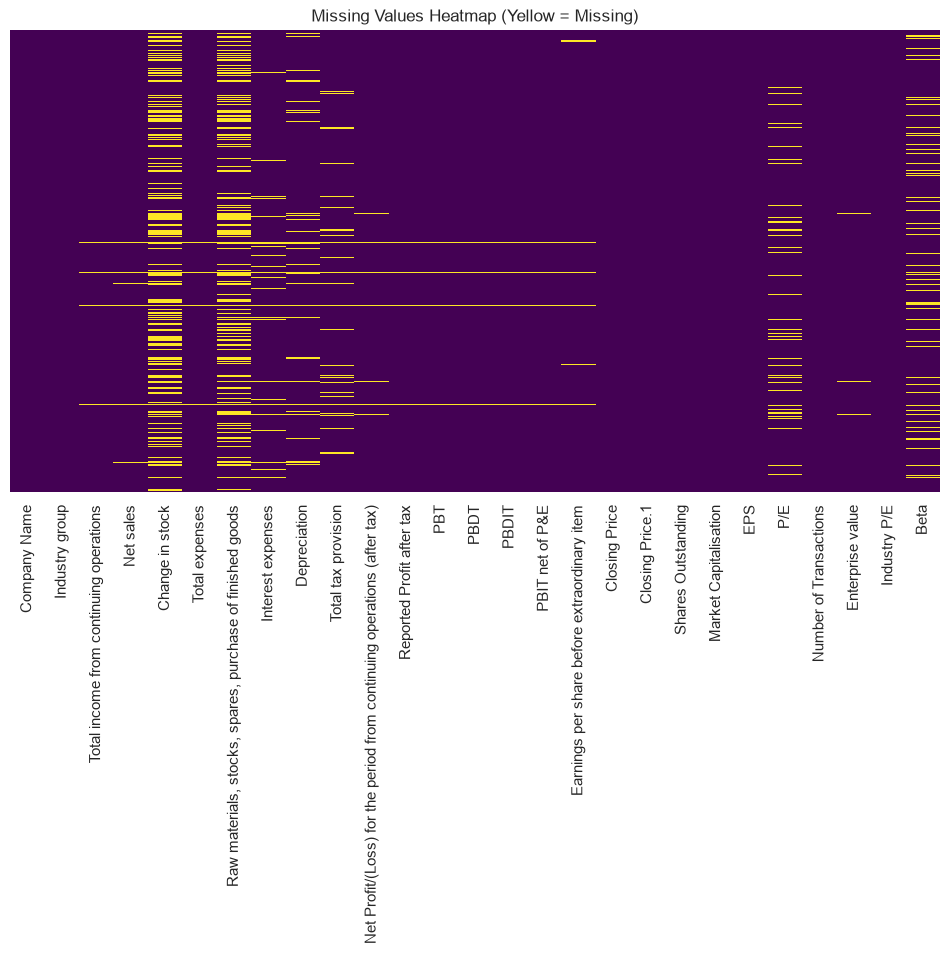

In [9]:
# Missing Values 
missing_pct = (df.isna().sum() / len(df)) * 100
missing_df = missing_pct[missing_pct > 0].sort_values(ascending=False).to_frame(name='Missing Percentage (%)')
display(missing_df.head(10))

plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Values Heatmap (Yellow = Missing)")
plt.show()


#### Interpretation : 
Several columns contain missing values. I will impute missing values using the **industry-wise median**. This is financially sound since firms within the same sector often share similar structural margins and ratios.

In [10]:
cols_to_impute = [col for col in numeric_cols if col not in ['Closing Price', 'Closing Price.1']]

for col in cols_to_impute:
    # Industry-wise median imputation
    df[col] = df.groupby("Industry group")[col].transform(lambda x: x.fillna(x.median()))
    
    # Fallback to global median if industry median is also NaN
    df[col] = df[col].fillna(df[col].median())

# We will drop rows where target prices are missing since we cannot construct the target variable
df = df.dropna(subset=['Closing Price', 'Closing Price.1'])

print(f"Total missing values after cleaning: {df.isna().sum().sum()}")


Total missing values after cleaning: 0


In [11]:
# Handling Duplicates : checking and removing duplicate rows

duplicates = df.duplicated().sum()
print(f"Number of duplicate records: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

Number of duplicate records: 0


## 5. Exploratory Data Analysis (EDA)
**Purpose**: Uncover patterns, distributions, correlations, and anomalies in the cleaned dataset. 
EDA validates assumptions and dictates the necessary feature engineering and transformation steps.

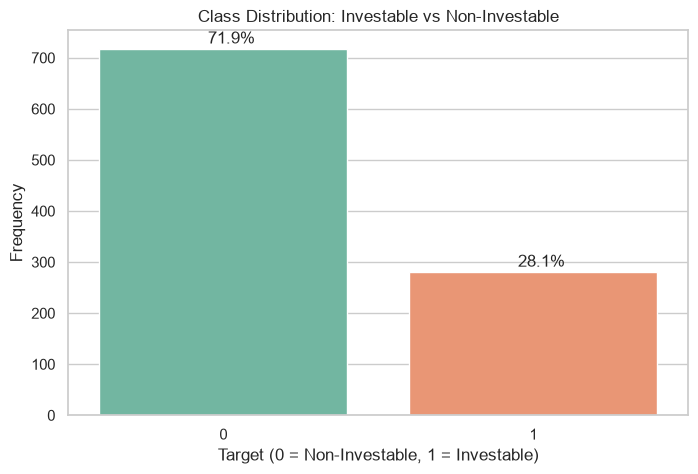

In [12]:
# first construct our target variable. calculating the forward return using the current and future closing prices. 
# A stock is considered Investable (1) if it exceeds a 9% return benchmark, and Non-Investable (0) otherwise.

# Construct Forward Return
df['Forward_Return'] = (df['Closing Price.1'] - df['Closing Price']) / df['Closing Price']

# Binary Target Formulation
df['Target_Investable'] = (df['Forward_Return'] >= 0.09).astype(int)

# Target Distribution Plot
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Target_Investable', data=df, palette='Set2')
plt.title("Class Distribution: Investable vs Non-Investable")
plt.xlabel("Target (0 = Non-Investable, 1 = Investable)")
plt.ylabel("Frequency")

# Add percentages
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height() + 10
    ax.annotate(percentage, (x, y), size=12)

plt.show()


### Interpretation
The target variable is moderately imbalanced. This imbalance suggests using Stratified Train-Test Split, Stratified K-Fold Cross-Validation, and algorithms such as Random Forest, XGBoost, or Logistic Regression with class weights, while evaluating performance using Precision, Recall, F1-score and ROC-AUC rather than accuracy alone.

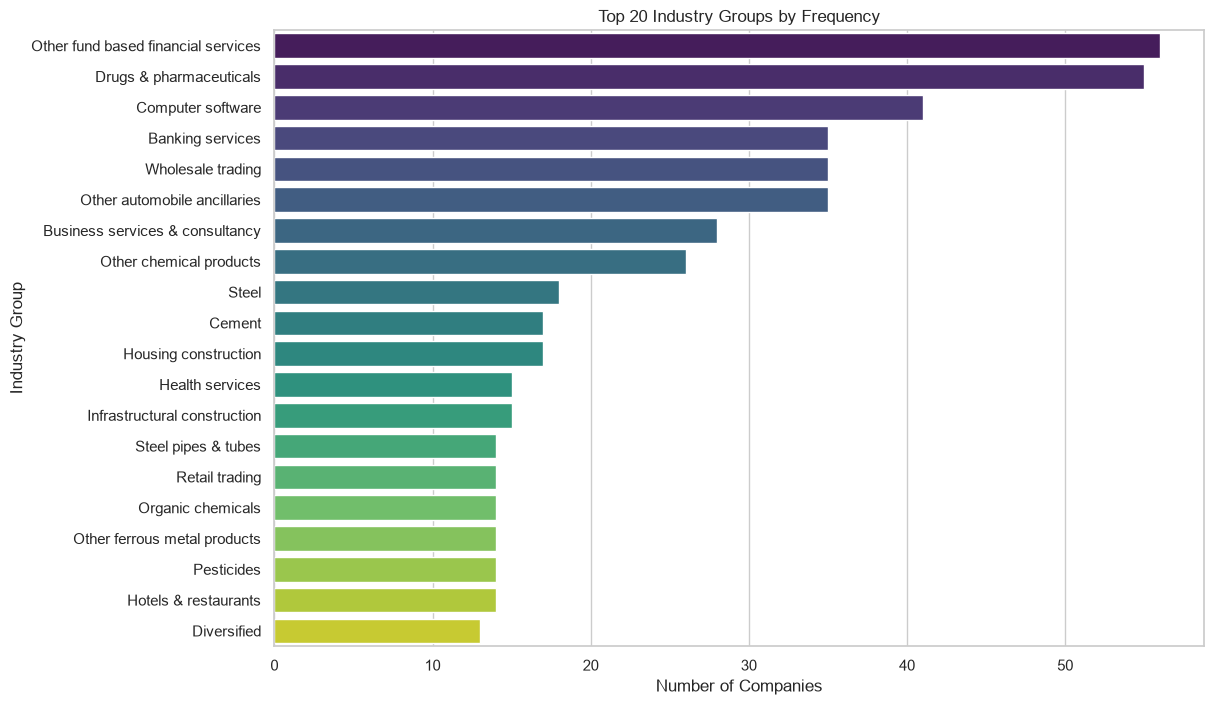

In [13]:
# examine the distribution of companies across industry groups.

plt.figure(figsize=(12, 8))
industry_counts = df['Industry group'].value_counts().head(20)
sns.barplot(y=industry_counts.index, x=industry_counts.values, palette='viridis')
plt.title("Top 20 Industry Groups by Frequency")
plt.xlabel("Number of Companies")
plt.ylabel("Industry Group")
plt.show()

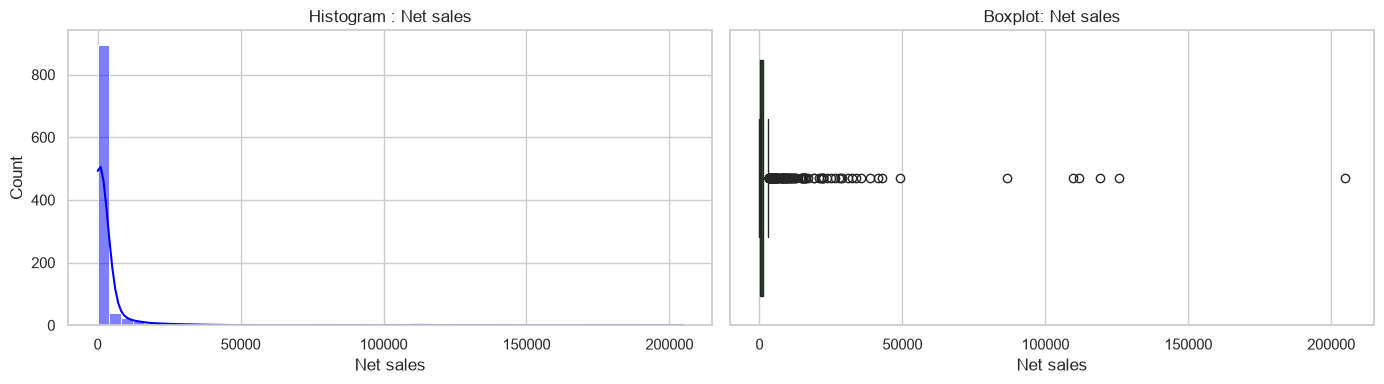

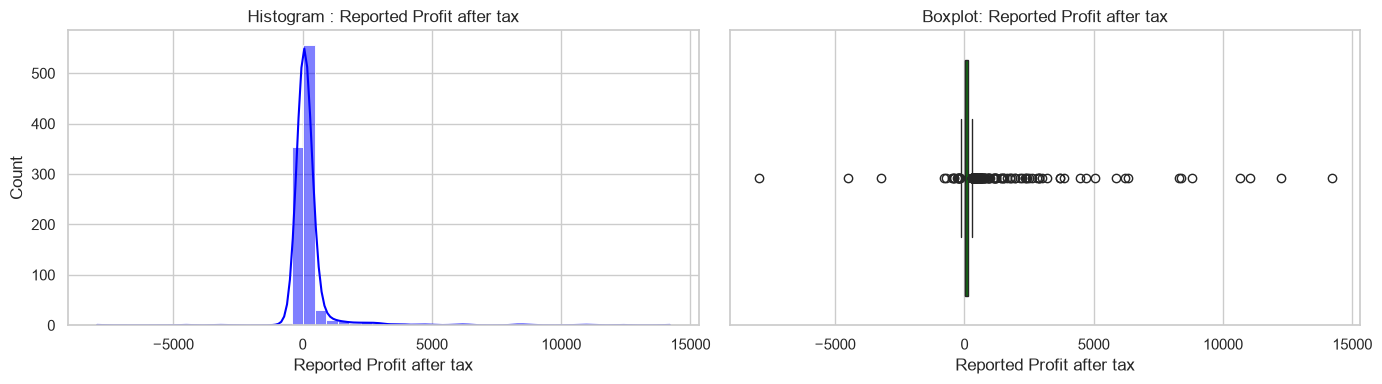

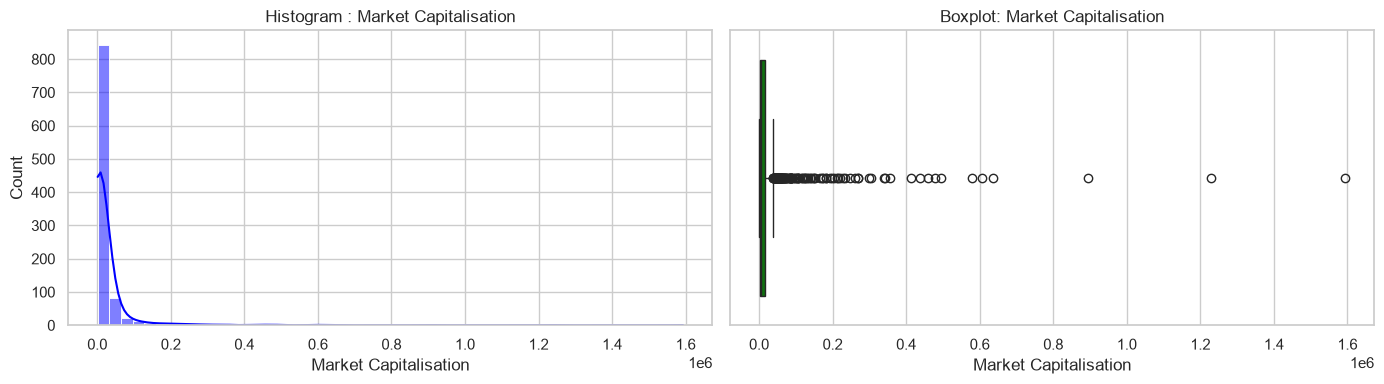

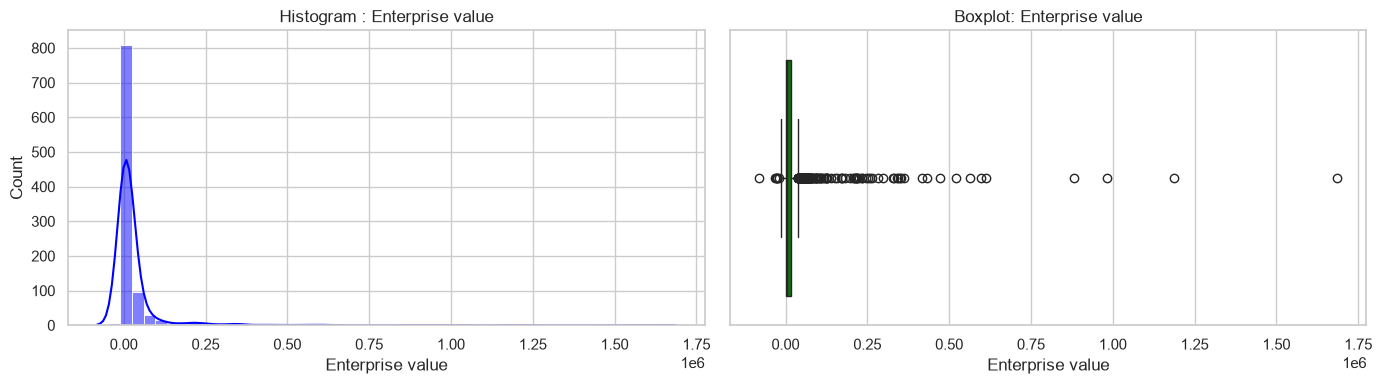

In [14]:

# visualize the distributions of key raw financial figures.

key_metrics = ['Net sales', 'Reported Profit after tax', 'Market Capitalisation', 'Enterprise value']

for col in key_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[0], color='blue', bins=50)
    axes[0].set_title(f'Histogram : {col}')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1], color='green')
    axes[1].set_title(f'Boxplot: {col}')
    
    plt.tight_layout()
    plt.show()

### Interpretation
The numerical features are highly right-skewed with heavy tails and contain several extreme values, which is common in financial datasets where a few large companies dominate the market. Log transformation (for highly skewed features) and if further needed Winsorization can be applied during preprocessing to reduce skewness and improve model performance.

In [16]:
# Outlier Analysis using IQR

numeric_cols = df.select_dtypes(include=['number']).columns.drop('Target_Investable')

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Outliers": outliers,
        "Outlier %": round(outliers/len(df)*100,2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df.sort_values("Outlier %", ascending=False)

,Feature,Outliers,Outlier %
2,Change in stock,290,29.03
5,Interest expenses,175,17.52
8,Net Profit/(Loss) for the period from continui...,153,15.32
9,Reported Profit after tax,147,14.71
17,Shares Outstanding,146,14.61
13,PBIT net of P&E,145,14.51
10,PBT,143,14.31
12,PBDIT,142,14.21
7,Total tax provision,142,14.21
22,Enterprise value,140,14.01


The IQR analysis indicates that many financial variables contain a high proportion of outliers (8–29%), particularly Change in Stock, Interest Expenses, Profit, Sales, Market Capitalisation, and Enterprise Value. In financial datasets, these extreme values are expected due to differences in company size and performance and are likely to represent genuine business variation rather than data errors. Therefore, these observations will be retained and addressed further

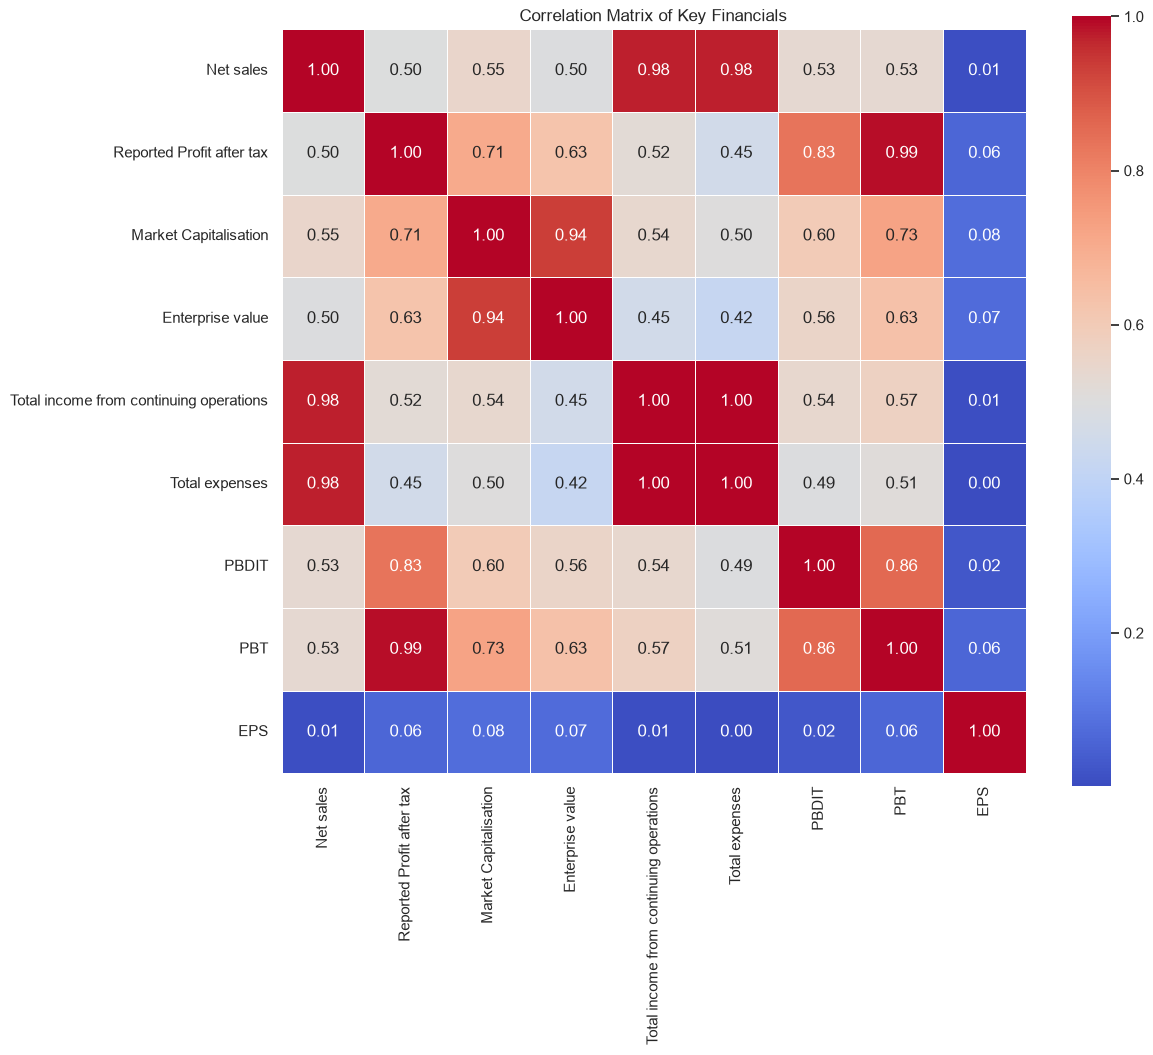

In [17]:
# Select a subset of important numeric columns for clarity
corr_cols = key_metrics + ['Total income from continuing operations', 'Total expenses', 'PBDIT', 'PBT', 'EPS']

plt.figure(figsize=(12, 10))
corr_matrix = df[corr_cols].corr()

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Correlation Matrix of Key Financials")
plt.show()


### Interpretation
The correlation matrix shows strong positive correlations among several raw financial variables, particularly Net Sales, Total Income, Total Expenses, Reported Profit after Tax, Market Capitalisation and Enterprise Value, indicating the presence of multicollinearity. 
This suggests that using financial ratios and derived features instead of raw financial values can reduce redundancy and improve the performance and interpretability of linear models, while tree-based models are generally less affected.

In [ ]:
# Relationship with target

numeric_cols = df.select_dtypes(include=['number']).columns.drop('Target_Investable')

for col in numeric_cols:
    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df,
        x='Target_Investable',
        y=col,
        palette='Set2'
    )

    plt.title(f'{col} vs Target')
    plt.xlabel('Target (0 = Non-Investable, 1 = Investable)')
    plt.ylabel(col)

    plt.show()

KeyError: "['Target'] not found in axis"

## 6. Feature Engineering
Ratios (like Margins, Returns, Valuations) standardize performance across varying company sizes and mitigate multicollinearity. Transform raw financials into robust, scaled and economically meaningful signals.

In [26]:
def safe_divide(numerator, denominator):
    return np.where((denominator == 0) | (denominator.isna()), np.nan, numerator / denominator)

df_fe = df.copy()

# -------------------------------------
# 1. Profitability Ratios
# -------------------------------------
df_fe["EBITDA_Margin"] = safe_divide(df_fe["PBDIT"], df_fe["Net sales"])
df_fe["Net_Profit_Margin"] = safe_divide(df_fe["Reported Profit after tax"], df_fe["Net sales"])
df_fe["ROA"] = safe_divide(df_fe["Reported Profit after tax"], df_fe["Enterprise value"])

# ROE (Return on Equity proxy using EPS / Price * Market Cap)
df_fe["ROE"] = safe_divide(df_fe["Reported Profit after tax"], 
                           safe_divide(df_fe["Market Capitalisation"], df_fe["Closing Price"]) * df_fe["EPS"])

# -------------------------------------
# 2. Leverage & Efficiency Ratios
# -------------------------------------
df_fe["Interest_Coverage"] = safe_divide(df_fe["PBT"] + df_fe["Interest expenses"], df_fe["Interest expenses"])
df_fe["Asset_Turnover"] = safe_divide(df_fe["Net sales"], df_fe["Enterprise value"])

# -------------------------------------
# 3. Valuation Ratios
# -------------------------------------
df_fe["PE_Computed"] = safe_divide(df_fe["Closing Price"], df_fe["EPS"])
df_fe["MarketCap_to_Sales"] = safe_divide(df_fe["Market Capitalisation"], df_fe["Net sales"])
df_fe["EV_to_Sales"] = safe_divide(df_fe["Enterprise value"], df_fe["Net sales"])

# Collect engineered features
engineered_features = [
    "EBITDA_Margin", "Net_Profit_Margin", "ROA", "ROE",
    "Interest_Coverage", "Asset_Turnover", 
    "PE_Computed", "MarketCap_to_Sales", "EV_to_Sales"
]

# Impute any resulting NaNs with industry median
for col in engineered_features:
    df_fe[col] = df_fe.groupby("Industry group")[col].transform(lambda x: x.fillna(x.median()))
    df_fe[col] = df_fe[col].fillna(df_fe[col].median())

# -------------------------------------
# 4. Outlier Handling: Winsorization : Ratios frequently blow up to infinity; we clip them at the 1st and 99th percentiles.
# -------------------------------------

for col in engineered_features:
    lower_bound = df_fe[col].quantile(0.01)
    upper_bound = df_fe[col].quantile(0.99)
    df_fe[col] = df_fe[col].clip(lower_bound, upper_bound)

display(df_fe[['Company Name', 'Target_Investable'] + engineered_features].head())


,Company Name,Target_Investable,EBITDA_Margin,Net_Profit_Margin,ROA,ROE,Interest_Coverage,Asset_Turnover,PE_Computed,MarketCap_to_Sales,EV_to_Sales
0,3M India Ltd.,0,0.177716,0.120969,0.004530,0.434267,271.053571,0.037451,100.407669,27.969510,26.701462
1,A B B India Ltd.,0,0.178626,0.125806,0.005377,0.882655,56.172652,0.042742,173.157253,24.680339,23.396406
2,A C C Ltd.,1,0.074913,0.024344,0.003660,0.140526,8.938927,0.150323,47.052188,8.151230,6.652346
3,A D F Foods Ltd.,1,0.283652,0.192643,0.012123,0.102064,167.875000,0.062929,8.903436,16.804935,15.891033
4,A G I Greenpac Ltd.,0,0.198237,0.093584,0.016456,0.737188,6.261234,0.175847,29.291147,3.718417,5.686759


### Interpretation
We successfully engineered 9 financial ratios representing profitability, leverage, efficiency, and valuation. By utilizing safe division, we avoided infinity errors. Finally, applying a 1% / 99% Winsorization effectively mitigated extreme spikes caused by negligible denominators (e.g., near-zero interest expenses or sales), ensuring the feature space is stable and ready for machine learning algorithms.
